[&#8592; Previous: ZIP to County Crosswalk](02_zip_county_crosswalk.ipynb)

# **Unsupervised Learning**

---

Look for structure in county MIPS performance on its own, with no outcome labels.
County by measure profiles are standardized, reduced with PCA, and grouped with
K-means, then each cluster is profiled against county Medicare outcomes to see what
the performance groups imply. The cluster labels export to the supervised notebook
for its residual checks.

**Setup:** Pinned dependencies: `python -m pip install -r ../requirements.txt`

## Table of Contents

1. [Load and filter to 2023](#s1)
2. [Pivot to county by measure](#s2)
3. [Imputation and scaling](#s3)
4. [PCA: dimensionality reduction](#s4)
5. [Clustering: county segmentation](#s5)
6. [Cluster profiling and outcome comparison](#s6)
7. [Summary and export](#s7)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.impute import SimpleImputer
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import kruskal

BLUE, MAIZE, GRAY = "#00274C", "#FFCB05", "#9aa0a6"
sns.set_theme(style="whitegrid", palette=[BLUE, MAIZE, GRAY])
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 200, "savefig.bbox": "tight", "svg.hashsalt": "mads-capstone",
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": BLUE,
    "axes.edgecolor": "#bbbbbb", "xtick.color": "#444444", "ytick.color": "#444444",
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": "#dddddd", "grid.linewidth": 0.8,
})
pd.set_option("display.max_columns", 60)

PROCESSED = Path("../data/processed")
FIGURES   = Path("../reports/figures")

---
<a id="s1"></a>

## **1. Load and filter to 2023**

Read the county by measure table built in notebook 02 and cut it to the 2023 performance year, the
same year the supervised notebook models, so the two arms describe the same counties.


In [2]:
am = pd.read_csv(PROCESSED / "analytic_measure.csv.gz", low_memory=False)
print(f"Full dataset: {am.shape[0]:,} rows  ×  {am.shape[1]} cols")
print(f"Years present: {sorted(am['YEAR'].unique())}")

Full dataset: 1,611,053 rows  ×  255 cols
Years present: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [3]:
am_2023 = am[am["YEAR"] == 2023].copy()
print(f"2023 only: {am_2023.shape[0]:,} rows")
print(f"Unique counties: {am_2023['county_fips'].nunique():,}")

has_mips = am_2023["measure_cd"].notna() & (am_2023["measure_cd"] != "")
print(f"Rows with MIPS data: {has_mips.sum():,}")
print(f"Rows without MIPS:   {(~has_mips).sum():,}")
print(f"Unique measures:     {am_2023.loc[has_mips, 'measure_cd'].nunique()}")

2023 only: 147,196 rows
Unique counties: 3,197
Rows with MIPS data: 146,954
Rows without MIPS:   242
Unique measures:     229


---
<a id="s2"></a>

## **2. Pivot to county by measure**

Reshape to one row per county and one column per measure, then look at how much of that grid is
actually populated. Measures reported in fewer than 30% of counties, and counties reporting fewer than 20% of those measures, are both dropped so the clustering is not driven by who reported rather than how
they performed.


In [4]:
am_mips = am_2023[has_mips].copy()

mips_wide = am_mips.pivot_table(
    index="county_fips",
    columns="measure_cd",
    values="avg_prf_rate_weighted",
    aggfunc="first",
)
print(f"Pivoted shape: {mips_wide.shape[0]:,} counties  ×  {mips_wide.shape[1]} measures")

Pivoted shape: 2,955 counties  ×  229 measures


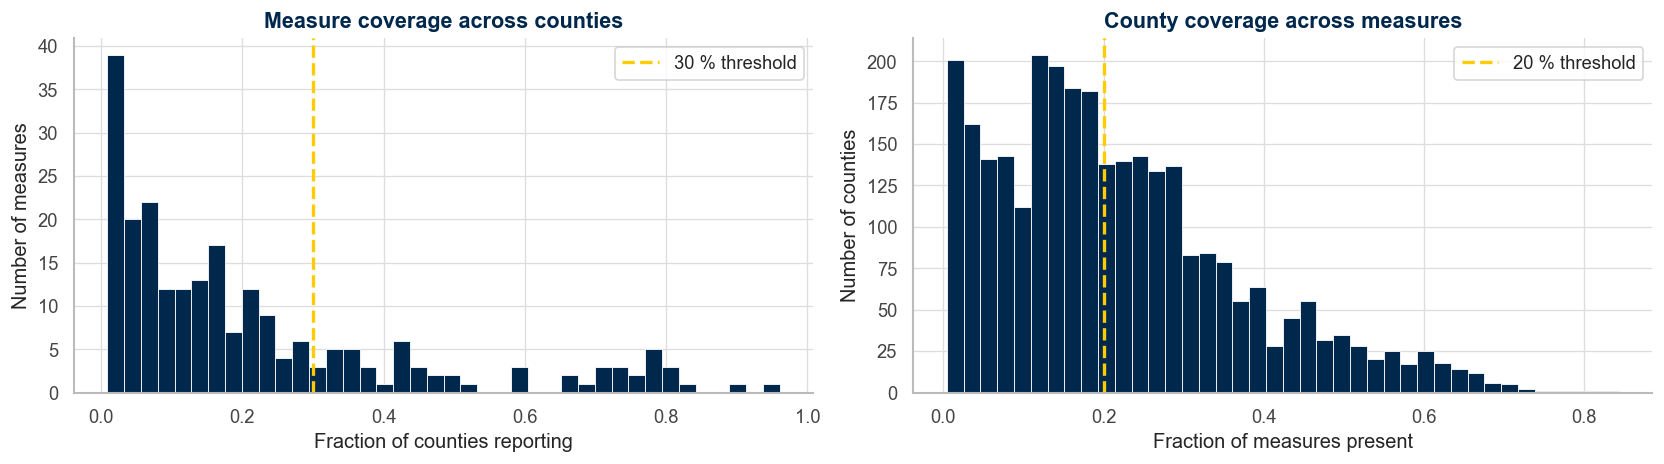

Measures above 30 % coverage: 55 / 229
Counties above 20 % measure coverage: 1400 / 2955


In [5]:
measure_coverage = mips_wide.notna().mean().sort_values(ascending=False)
county_coverage  = mips_wide.notna().mean(axis=1).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(measure_coverage, bins=40, color=BLUE, edgecolor="white", linewidth=0.5)
axes[0].set_xlabel("Fraction of counties reporting")
axes[0].set_ylabel("Number of measures")
axes[0].set_title("Measure coverage across counties")
axes[0].axvline(0.30, color=MAIZE, lw=2, ls="--", label="30 % threshold")
axes[0].legend()

axes[1].hist(county_coverage, bins=40, color=BLUE, edgecolor="white", linewidth=0.5)
axes[1].set_xlabel("Fraction of measures present")
axes[1].set_ylabel("Number of counties")
axes[1].set_title("County coverage across measures")
axes[1].axvline(0.20, color=MAIZE, lw=2, ls="--", label="20 % threshold")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Measures above 30 % coverage: {(measure_coverage >= 0.30).sum()} / {len(measure_coverage)}")
print(f"Counties above 20 % measure coverage: {(county_coverage >= 0.20).sum()} / {len(county_coverage)}")

In [6]:
MEASURE_THRESH = 0.30
COUNTY_THRESH  = 0.20

keep_measures = measure_coverage[measure_coverage >= MEASURE_THRESH].index
mips_filtered = mips_wide[keep_measures]

keep_counties = county_coverage[county_coverage >= COUNTY_THRESH].index
mips_filtered = mips_filtered.loc[mips_filtered.index.isin(keep_counties)]

print(f"After filtering: {mips_filtered.shape[0]:,} counties  ×  {mips_filtered.shape[1]} measures")
print(f"Remaining NaN fraction: {mips_filtered.isna().mean().mean():.3f}")

After filtering: 1,400 counties  ×  55 measures
Remaining NaN fraction: 0.205


---
<a id="s3"></a>

## **3. Imputation and scaling**

Fill the remaining gaps with the measure median and standardize every column, so that measures on
different scales contribute equally to the distance calculations that follow.


In [7]:
imputer = SimpleImputer(strategy="median")
mips_imputed = pd.DataFrame(
    imputer.fit_transform(mips_filtered),
    index=mips_filtered.index,
    columns=mips_filtered.columns,
)

scaler = StandardScaler()
mips_scaled = pd.DataFrame(
    scaler.fit_transform(mips_imputed),
    index=mips_imputed.index,
    columns=mips_imputed.columns,
)

print(f"Scaled matrix: {mips_scaled.shape}")
print(f"Mean ≈ 0: {mips_scaled.mean().mean():.6f}")
print(f"Std  ≈ 1: {mips_scaled.std().mean():.6f}")

Scaled matrix: (1400, 55)
Mean ≈ 0: 0.000000
Std  ≈ 1: 1.000357


---
<a id="s4"></a>

## **4. PCA: dimensionality reduction**

Ask whether county performance profiles are really as high dimensional as their measure count
suggests. The scree curve fixes how many components carry 90% of the variance, and the loadings
say what those components represent.


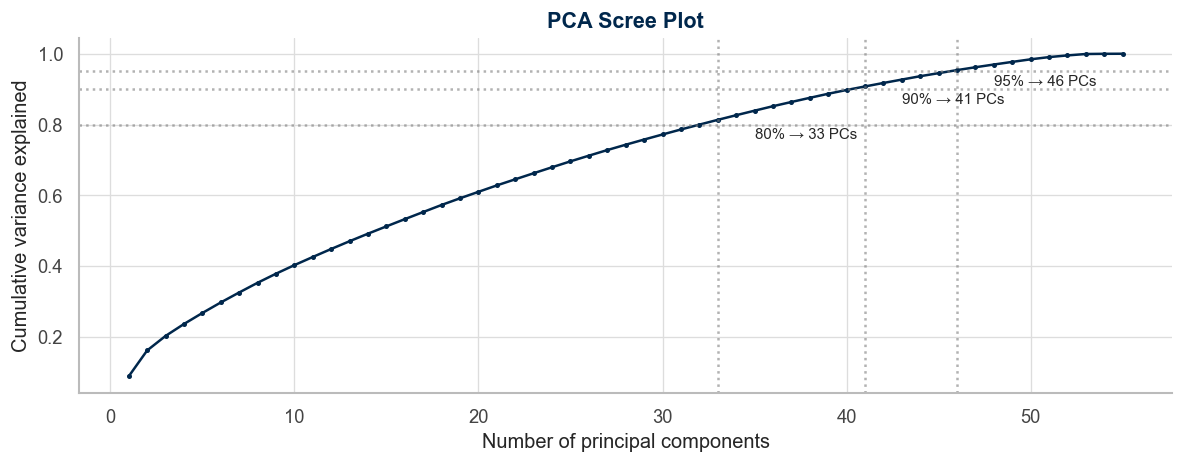

In [8]:
pca_full = PCA().fit(mips_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(cum_var) + 1), cum_var, marker=".", markersize=4)
for thresh in [0.80, 0.90, 0.95]:
    n = np.searchsorted(cum_var, thresh) + 1
    ax.axhline(thresh, color="grey", ls=":", alpha=0.6)
    ax.axvline(n, color="grey", ls=":", alpha=0.6)
    ax.annotate(f"{thresh:.0%} → {n} PCs", xy=(n, thresh),
                xytext=(n + 2, thresh - 0.04), fontsize=9)
ax.set_xlabel("Number of principal components")
ax.set_ylabel("Cumulative variance explained")
ax.set_title("PCA Scree Plot")
plt.tight_layout()
plt.show()

In [9]:
N_COMPONENTS = np.searchsorted(cum_var, 0.90) + 1
print(f"Retaining {N_COMPONENTS} components (≥ 90 % variance)")

pca = PCA(n_components=N_COMPONENTS)
pca_scores = pd.DataFrame(
    pca.fit_transform(mips_scaled),
    index=mips_scaled.index,
    columns=[f"PC{i+1}" for i in range(N_COMPONENTS)],
)

Retaining 41 components (≥ 90 % variance)


In [10]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=mips_scaled.columns,
    columns=[f"PC{i+1}" for i in range(N_COMPONENTS)],
)

n_top = 10
for pc in ["PC1", "PC2", "PC3"]:
    top = loadings[pc].abs().nlargest(n_top)
    print(f"\n--- {pc} top-{n_top} loadings ---")
    print(loadings.loc[top.index, pc].sort_values(ascending=False).to_string())


--- PC1 top-10 loadings ---
measure_cd
MIPS_GRP_112_overall                0.333615
MIPS_GRP_226_combinedPopulations    0.299248
MIPS_GRP_226_screened               0.282826
MIPS_GRP_309_overall                0.273190
MIPS_GRP_113_overall                0.268800
MIPS_GRP_134_overall                0.261157
MIPS_GRP_475_overall                0.233560
MIPS_GRP_236_overall                0.216707
MIPS_GRP_318_overall                0.214036
MIPS_GRP_001_overall               -0.228972

--- PC2 top-10 loadings ---
measure_cd
MIPS_GRP_238_totalRate               0.430830
MIPS_GRP_238_overall                 0.423651
MIPS_GRP_238_appropriateDiagnosis    0.370183
MIPS_GRP_472_overall                 0.158748
MIPS_GRP_001_overall                -0.155522
MIPS_GRP_019_overall                -0.176931
MIPS_GRP_012_overall                -0.205605
MIPS_GRP_374_overall                -0.231231
MIPS_GRP_143_overall                -0.250644
MIPS_GRP_117_overall                -0.264825

--- PC3 t

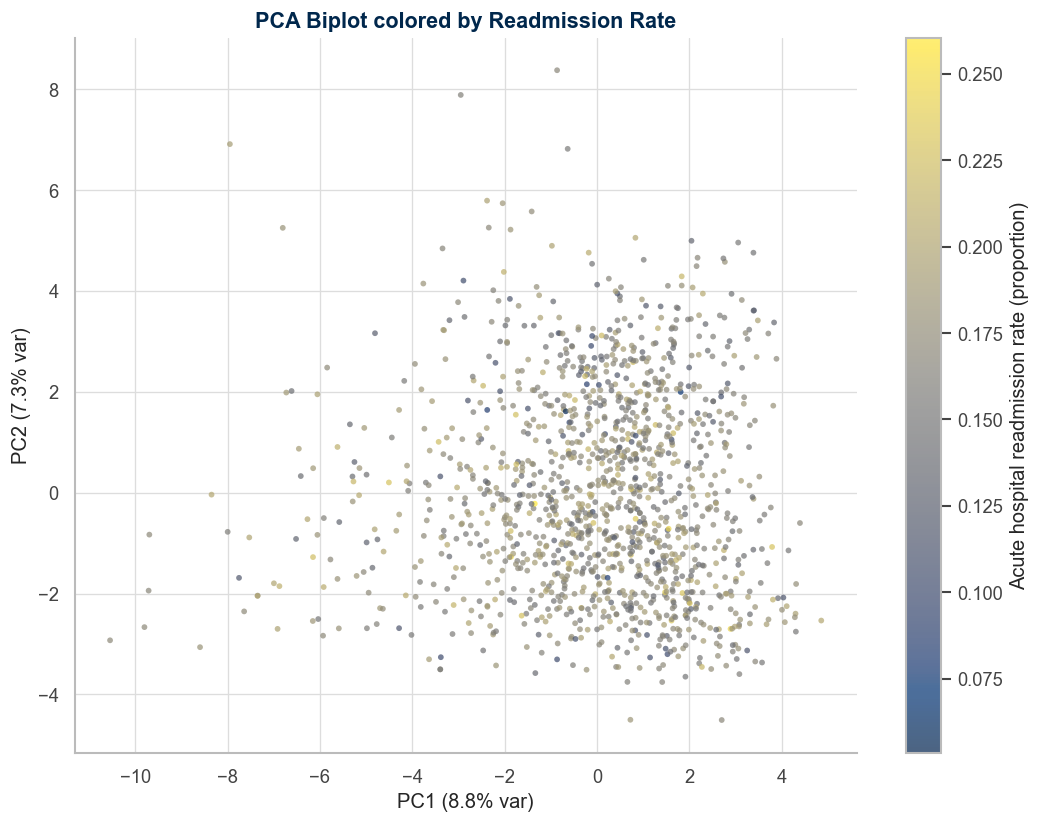

In [11]:
geo_2023 = am_2023.drop_duplicates(subset="county_fips").set_index("county_fips")

readmit_col = "ACUTE_HOSP_READMSN_PCT"
plot_df = pca_scores.join(geo_2023[[readmit_col]], how="inner")
plot_df[readmit_col] = pd.to_numeric(plot_df[readmit_col], errors="coerce")
plot_df = plot_df.dropna(subset=[readmit_col])

fig, ax = plt.subplots(figsize=(9, 7))
sc = ax.scatter(
    plot_df["PC1"], plot_df["PC2"],
    c=plot_df[readmit_col], cmap="cividis",
    s=12, alpha=0.7, edgecolors="none",
)
plt.colorbar(sc, ax=ax, label="Acute hospital readmission rate (proportion)")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("PCA Biplot colored by Readmission Rate")
plt.tight_layout()
plt.show()

---
<a id="s5"></a>

## **5. Clustering: county segmentation**

Sweep k from 2 to 10 and score each with the silhouette, then fit k-means at the best value and
check the shape with a hierarchical dendrogram. The question is whether counties fall into
distinguishable performance archetypes or sit on a continuum.


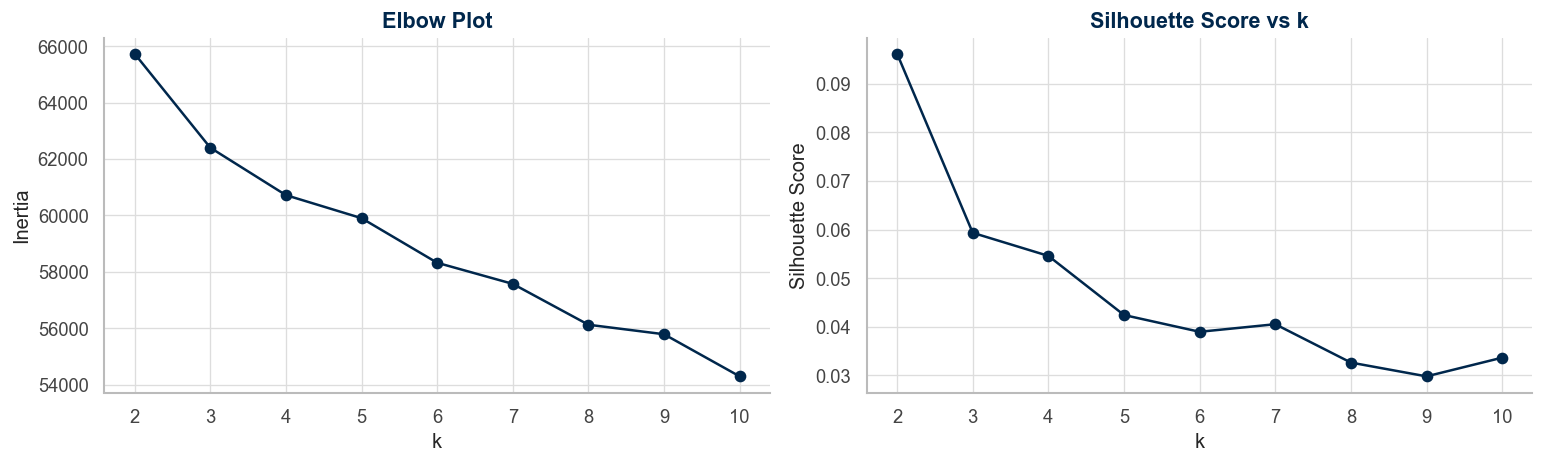

Best silhouette at k = 2  (score = 0.096)


In [12]:
K_RANGE = range(2, 11)
inertias, sil_scores = [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(pca_scores)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(pca_scores, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(K_RANGE), inertias, marker="o")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow Plot")

axes[1].plot(list(K_RANGE), sil_scores, marker="o")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("Silhouette Score vs k")

plt.tight_layout()
plt.show()

best_k = list(K_RANGE)[np.argmax(sil_scores)]
print(f"Best silhouette at k = {best_k}  (score = {max(sil_scores):.3f})")

In [13]:
CHOSEN_K = best_k
km_final = KMeans(n_clusters=CHOSEN_K, n_init=20, random_state=42)
pca_scores["cluster"] = km_final.fit_predict(pca_scores)

print(f"K-Means with k = {CHOSEN_K}")
print(pca_scores["cluster"].value_counts().sort_index())

K-Means with k = 2
cluster
0    445
1    955
Name: count, dtype: int64


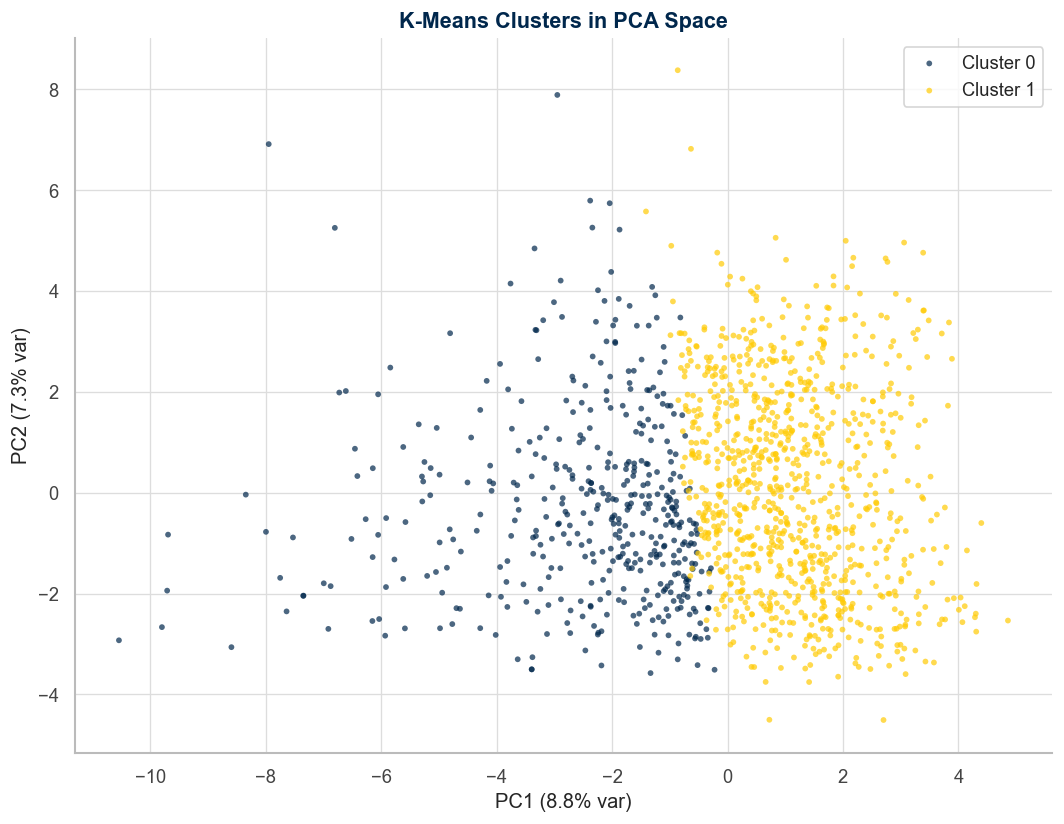

In [14]:
fig, ax = plt.subplots(figsize=(9, 7))
for c in sorted(pca_scores["cluster"].unique()):
    mask = pca_scores["cluster"] == c
    ax.scatter(
        pca_scores.loc[mask, "PC1"],
        pca_scores.loc[mask, "PC2"],
        label=f"Cluster {c}", s=12, alpha=0.7, edgecolors="none",
    )
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var)")
ax.set_title("K-Means Clusters in PCA Space")
ax.legend()
plt.tight_layout()
plt.show()

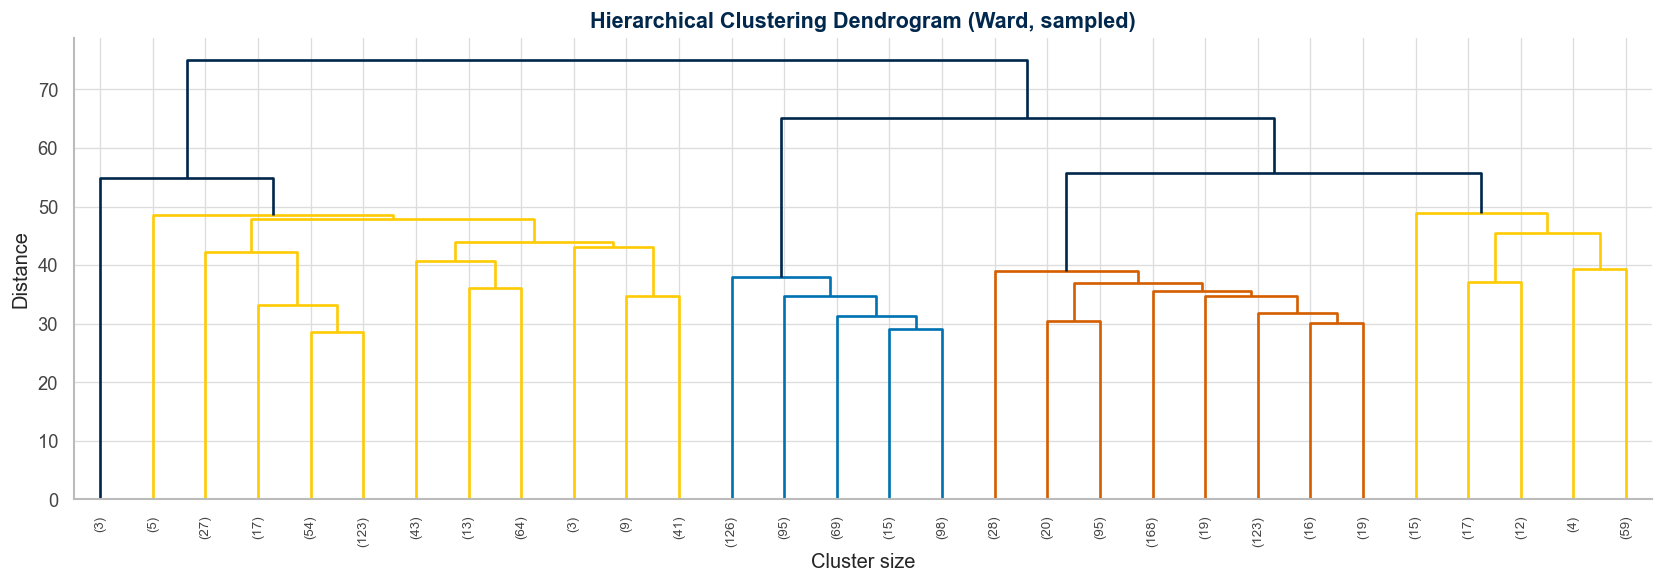

In [15]:
# Truncated dendrogram: truncate_mode="lastp" collapses the tree to its last 30
# merges so the structure is readable, and the sample is capped at 2,000 counties
# so the leaf labels stay legible.
sample_idx = mips_scaled.sample(n=min(2000, len(mips_scaled)), random_state=42).index
Z = linkage(mips_scaled.loc[sample_idx], method="ward")

from scipy.cluster.hierarchy import set_link_color_palette
set_link_color_palette([MAIZE, "#0072B2", "#D55E00"])

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90,
           leaf_font_size=8, above_threshold_color=BLUE, ax=ax)
for coll in ax.collections:
    coll.set_linewidth(1.6)
ax.set_title("Hierarchical Clustering Dendrogram (Ward, sampled)")
ax.set_xlabel("Cluster size")
ax.set_ylabel("Distance")
plt.tight_layout()
plt.show()

---
<a id="s6"></a>

## **6. Cluster profiling and outcome comparison**

Having grouped counties on MIPS performance alone, with no outcome data involved, compare the
clusters on county Medicare outcomes to see whether the performance groups differ on anything a
patient would notice.


In [16]:
county_outcome_cols = [
    "ACUTE_HOSP_READMSN_CNT", "ACUTE_HOSP_READMSN_PCT",
    "BENES_ER_VISITS_CNT", "ER_VISITS_PER_1000_BENES", "BENES_ER_VISITS_PCT",
    "BENES_IP_PCT", "IP_CVRD_STAYS_PER_1000_BENES", "IP_CVRD_DAYS_PER_1000_BENES",
    "IP_MDCR_PYMT_PER_USER", "IP_MDCR_STDZD_PYMT_PER_USER",
    "BENES_OP_PCT", "OP_VISITS_PER_1000_BENES",
    "OP_MDCR_PYMT_PER_USER", "OP_MDCR_STDZD_PYMT_PER_USER",
    "BENES_EM_PCT", "EM_EVNTS_PER_1000_BENES",
    "EM_MDCR_PYMT_PER_USER", "EM_MDCR_STDZD_PYMT_PER_USER",
    "BENES_SNF_PCT", "SNF_CVRD_STAYS_PER_1000_BENES", "SNF_CVRD_DAYS_PER_1000_BENES",
    "SNF_MDCR_PYMT_PER_USER", "SNF_MDCR_STDZD_PYMT_PER_USER",
    "BENES_HH_PCT", "HH_EPISODES_PER_1000_BENES", "HH_VISITS_PER_1000_BENES",
    "HH_MDCR_PYMT_PER_USER", "HH_MDCR_STDZD_PYMT_PER_USER",
    "BENES_HOSPC_PCT", "HOSPC_CVRD_STAYS_PER_1000_BENES", "HOSPC_CVRD_DAYS_PER_1000_BENES",
    "HOSPC_MDCR_PYMT_PER_USER", "HOSPC_MDCR_STDZD_PYMT_PER_USER",
    "PRCDR_EVNTS_PER_1000_BENES", "TESTS_EVNTS_PER_1000_BENES", "IMGNG_EVNTS_PER_1000_BENES",
    "PRCDRS_MDCR_STDZD_PYMT_PER_USER", "TESTS_MDCR_STDZD_PYMT_PER_USER", "IMGNG_MDCR_STDZD_PYMT_PER_USER",
    "DME_EVNTS_PER_1000_BENES", "AMBLNC_EVNTS_PER_1000_BENES", "FQHC_RHC_VISITS_PER_1000_BENES",
    "DME_MDCR_STDZD_PYMT_PER_USER", "AMBLNC_MDCR_STDZD_PYMT_PER_USER",
]

demo_cols = ["BENE_AVG_AGE", "BENE_FEML_PCT", "BENE_RACE_WHT_PCT",
             "BENE_RACE_BLACK_PCT", "BENE_DUAL_PCT", "BENES_TOTAL_CNT"]

profile_cols = demo_cols + county_outcome_cols
available_cols = [c for c in profile_cols if c in geo_2023.columns]

profile_df = pca_scores[["cluster"]].join(geo_2023[available_cols], how="inner")
for col in available_cols:
    profile_df[col] = pd.to_numeric(profile_df[col], errors="coerce")

print(f"Profile DataFrame: {profile_df.shape}")

Profile DataFrame: (1400, 51)


In [17]:
cluster_means = profile_df.groupby("cluster")[available_cols].mean()
cluster_means.round(2)

,BENE_AVG_AGE,BENE_FEML_PCT,BENE_RACE_WHT_PCT,BENE_RACE_BLACK_PCT,BENE_DUAL_PCT,BENES_TOTAL_CNT,ACUTE_HOSP_READMSN_CNT,ACUTE_HOSP_READMSN_PCT,BENES_ER_VISITS_CNT,ER_VISITS_PER_1000_BENES,BENES_ER_VISITS_PCT,BENES_IP_PCT,IP_CVRD_STAYS_PER_1000_BENES,IP_CVRD_DAYS_PER_1000_BENES,IP_MDCR_PYMT_PER_USER,IP_MDCR_STDZD_PYMT_PER_USER,BENES_OP_PCT,OP_VISITS_PER_1000_BENES,OP_MDCR_PYMT_PER_USER,OP_MDCR_STDZD_PYMT_PER_USER,BENES_EM_PCT,EM_EVNTS_PER_1000_BENES,EM_MDCR_PYMT_PER_USER,EM_MDCR_STDZD_PYMT_PER_USER,BENES_SNF_PCT,SNF_CVRD_STAYS_PER_1000_BENES,SNF_CVRD_DAYS_PER_1000_BENES,SNF_MDCR_PYMT_PER_USER,SNF_MDCR_STDZD_PYMT_PER_USER,BENES_HH_PCT,HH_EPISODES_PER_1000_BENES,HH_VISITS_PER_1000_BENES,HH_MDCR_PYMT_PER_USER,HH_MDCR_STDZD_PYMT_PER_USER,BENES_HOSPC_PCT,HOSPC_CVRD_STAYS_PER_1000_BENES,HOSPC_CVRD_DAYS_PER_1000_BENES,HOSPC_MDCR_PYMT_PER_USER,HOSPC_MDCR_STDZD_PYMT_PER_USER,PRCDR_EVNTS_PER_1000_BENES,TESTS_EVNTS_PER_1000_BENES,IMGNG_EVNTS_PER_1000_BENES,PRCDRS_MDCR_STDZD_PYMT_PER_USER,TESTS_MDCR_STDZD_PYMT_PER_USER,IMGNG_MDCR_STDZD_PYMT_PER_USER,DME_EVNTS_PER_1000_BENES,AMBLNC_EVNTS_PER_1000_BENES,FQHC_RHC_VISITS_PER_1000_BENES,DME_MDCR_STDZD_PYMT_PER_USER,AMBLNC_MDCR_STDZD_PYMT_PER_USER
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,72.60,0.54,0.85,0.07,0.15,37642.54,606.92,0.17,8967.79,595.40,0.30,0.14,221.70,1174.08,23107.93,19276.03,0.69,4764.08,3345.43,3386.19,0.89,12809.73,1116.43,1159.71,0.04,52.30,1410.10,19709.26,22142.58,0.08,273.49,2072.23,5375.50,5978.44,0.03,32.91,2521.96,13406.81,14447.86,2730.15,5926.97,4250.29,841.57,452.01,294.42,1932.72,312.81,915.94,2018.97,1136.00
1,72.77,0.54,0.85,0.06,0.14,44775.69,692.89,0.17,10436.00,591.28,0.29,0.14,212.86,1117.85,23519.13,19167.68,0.71,5332.66,3515.37,3513.79,0.90,12620.78,1094.14,1131.15,0.04,50.97,1318.43,18844.35,20748.23,0.08,227.18,1790.35,5074.69,5488.55,0.03,32.61,2435.71,13487.10,14309.25,2720.67,5468.60,4162.23,810.88,406.92,279.21,1837.27,304.52,622.86,1811.17,1030.91


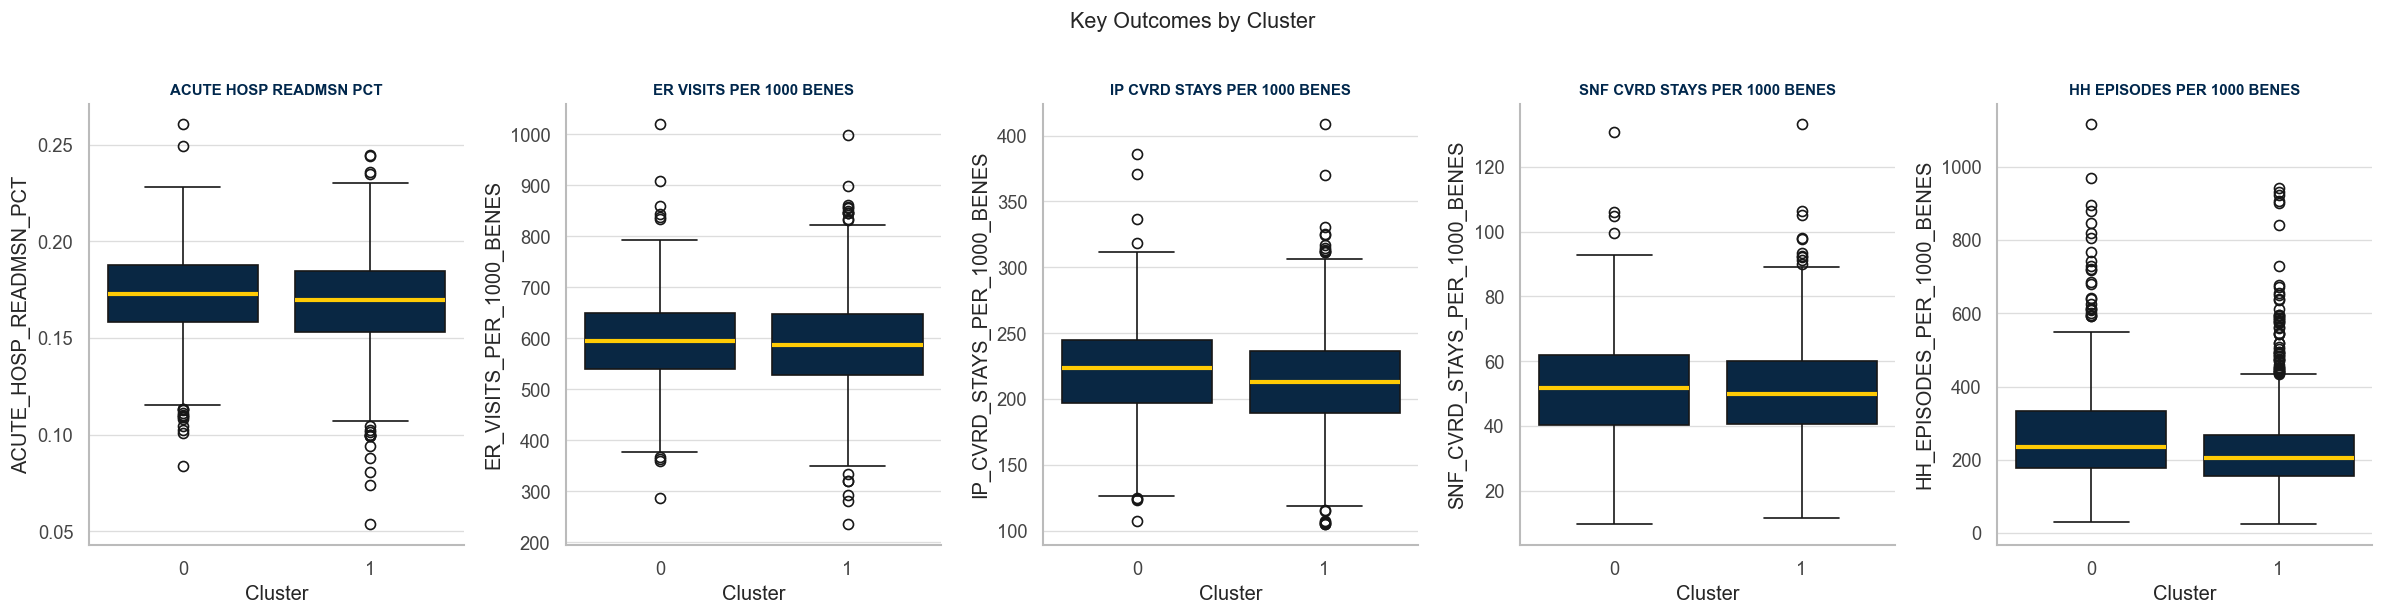

In [18]:
highlight_outcomes = [
    "ACUTE_HOSP_READMSN_PCT", "ER_VISITS_PER_1000_BENES",
    "IP_CVRD_STAYS_PER_1000_BENES", "SNF_CVRD_STAYS_PER_1000_BENES",
    "HH_EPISODES_PER_1000_BENES",
]
plot_outcomes = [c for c in highlight_outcomes if c in available_cols]

fig, axes = plt.subplots(1, len(plot_outcomes), figsize=(4 * len(plot_outcomes), 5),
                         sharey=False)
if len(plot_outcomes) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_outcomes):
    sns.boxplot(data=profile_df, x="cluster", y=col, color=BLUE,
                medianprops={"color": MAIZE, "linewidth": 2.5}, ax=ax)
    ax.set_title(col.replace("_", " "), fontsize=9)
    ax.set_xlabel("Cluster")

plt.suptitle("Key Outcomes by Cluster", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

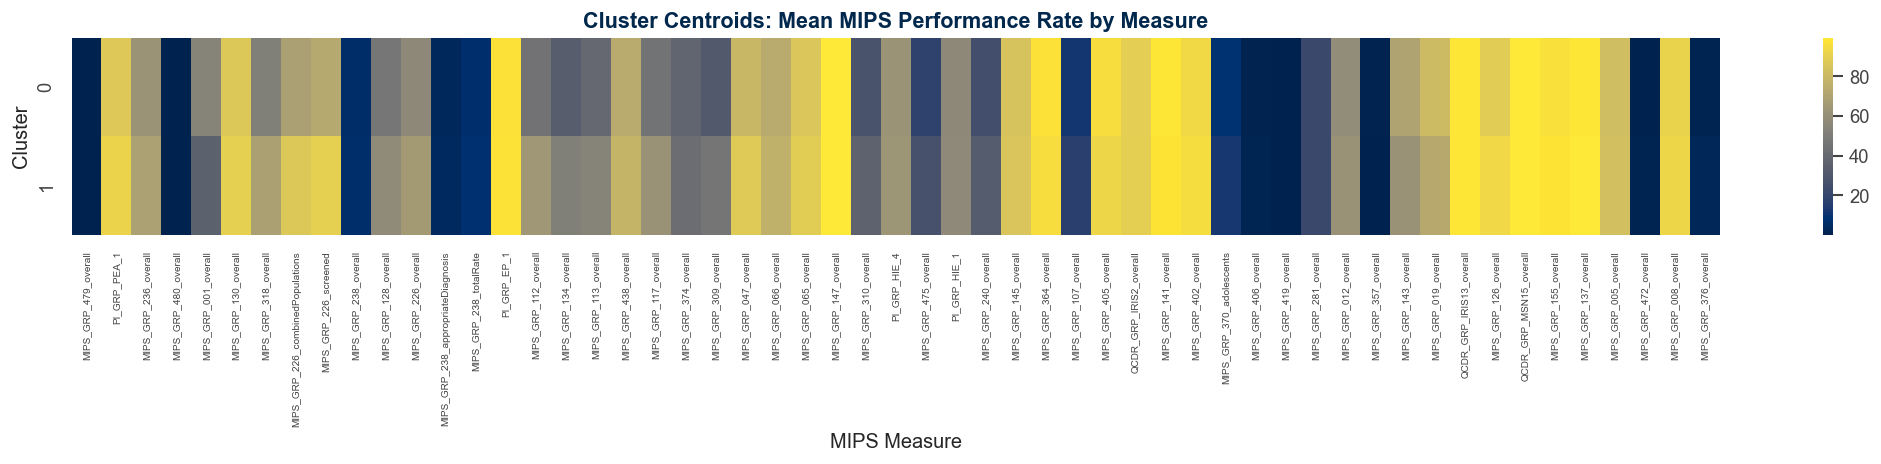

In [19]:
centroid_mips = mips_imputed.copy()
centroid_mips["cluster"] = pca_scores["cluster"]
centroid_means = centroid_mips.groupby("cluster").mean()

fig, ax = plt.subplots(figsize=(18, max(4, CHOSEN_K * 1.2)))
sns.heatmap(centroid_means, cmap="cividis", ax=ax, xticklabels=True, yticklabels=True)
ax.set_title("Cluster Centroids: Mean MIPS Performance Rate by Measure")
ax.set_xlabel("MIPS Measure")
ax.set_ylabel("Cluster")
ax.tick_params(axis="x", labelsize=6, rotation=90)
plt.tight_layout()
plt.show()

In [20]:
test_outcomes = [c for c in county_outcome_cols if c in available_cols]
kruskal_results = []

for col in test_outcomes:
    groups = [g[col].dropna().values for _, g in profile_df.groupby("cluster")]
    groups = [g for g in groups if len(g) >= 5]
    if len(groups) >= 2:
        stat, pval = kruskal(*groups)
        kruskal_results.append({"outcome": col, "H_statistic": round(stat, 2),
                                "p_value": pval})

kw_df = pd.DataFrame(kruskal_results).sort_values("p_value")
kw_df["significant_005"] = kw_df["p_value"] < 0.05
print(f"{kw_df['significant_005'].sum()} / {len(kw_df)} outcomes significantly differ across clusters (p < .05)")
kw_df.head(15)

28 / 44 outcomes significantly differ across clusters (p < .05)


,outcome,H_statistic,p_value,significant_005
37,TESTS_MDCR_STDZD_PYMT_PER_USER,53.94,2.070915e-13,True
27,HH_MDCR_STDZD_PYMT_PER_USER,48.85,2.764128e-12,True
24,HH_EPISODES_PER_1000_BENES,34.04,5.389636e-09,True
42,DME_MDCR_STDZD_PYMT_PER_USER,33.90,5.808819e-09,True
41,FQHC_RHC_VISITS_PER_1000_BENES,31.50,1.998336e-08,True
36,PRCDRS_MDCR_STDZD_PYMT_PER_USER,29.74,4.953166e-08,True
26,HH_MDCR_PYMT_PER_USER,29.30,6.208346e-08,True
43,AMBLNC_MDCR_STDZD_PYMT_PER_USER,27.35,1.698798e-07,True
25,HH_VISITS_PER_1000_BENES,24.08,9.220366e-07,True
11,OP_VISITS_PER_1000_BENES,24.00,9.627862e-07,True


---
<a id="s7"></a>

## **7. Summary and export**

State what the clustering did and did not find, and write the county cluster labels that the
supervised notebook reads for its residual checks.


In [21]:
cluster_export = pca_scores[["cluster"]].copy()
cluster_export = cluster_export.join(geo_2023[["BENE_GEO_DESC"]], how="left")
cluster_export.to_csv(PROCESSED / "county_clusters.csv")
print(f"Exported {len(cluster_export)} county cluster assignments to {PROCESSED / 'county_clusters.csv'}")
cluster_export.head(10)

Exported 1400 county cluster assignments to ../data/processed/county_clusters.csv


,cluster,BENE_GEO_DESC
county_fips,,
1003,1,AL-Baldwin
1009,0,AL-Blount
1011,1,AL-Bullock
1015,0,AL-Calhoun
1017,0,AL-Chambers
1019,0,AL-Cherokee
1027,0,AL-Clay
1029,0,AL-Cleburne
1031,1,AL-Coffee


### Interpretation

**PCA results.** 41 components are needed to reach 90% cumulative variance
across 55 measures, which means MIPS performance is not dominated by a single
 axis. PC1 loads most heavily on preventive screening measures (MIPS 112: Breast Cancer Screening,
MIPS 226: Tobacco Use Screening, MIPS 309: Cervical Cancer Screening) and
clinical management (MIPS 113, 134). MIPS 001 (HbA1c Poor Control) loads
negatively, which is expected because it is an inverse measure (higher rate =
worse control). PC1 therefore separates counties with strong preventive care
from those with weaker performance. PC2 is dominated by MIPS 238 (Use of
High-Risk Medications in Older Adults), with chronic disease management
measures (MIPS 117, 143) loading in the opposite direction.

**Clustering results.** The best silhouette score is 0.096 at k = 2. This is a low
value indicating that counties do not form distinct performance archetypes.
Performance varies along a continuum rather than splitting into clearly
separable "high" and "low" groups. The two clusters are also imbalanced
(445 vs. 955 counties), with the smaller cluster likely capturing counties
at one tail end of the PC1 distribution.

**Outcome comparison.** Despite the weak cluster separation, 28 of 44 Medicare
outcomes differ significantly across the two clusters (p < 0.05). The strongest
differentiators are utilization and cost measures: standardized payments for
tests (H = 53.9, p ≈ 10⁻¹³), home health payments (H = 48.9, p ≈ 10⁻¹²),
DME costs (H = 33.9, p ≈ 10⁻⁹), and FQHC/RHC visits (H = 31.5, p ≈ 10⁻⁸).
Acute outcomes like readmission and ER rates show weaker separation, suggesting
that MIPS performance profiles are more closely associated with practice
patterns and resource use than with patient-level clinical events.

**Limitations.**
- Observational, cross-sectional data (2023 MIPS × 2023 geo). No causal claims can be made.
- about 53% of the counties carrying any MIPS data were excluded here for sparse coverage, leaving 1,400.
  Surviving counties are likely larger and more urban.
- Median imputation fills ~20% of cells, potentially attenuating real differences.
- Cluster labels are exported for downstream use in supervised learning.

---
[Next: Supervised Learning &#8594;](04_supervised_learning.ipynb)